## Plotting gene expression embeddings

This is a quick and dirty way to visualize the expression of a specific gene in the UMAP embedding of the TAL dataset. I wrote a custom function to plot the gene expression across a series of conditions.


In [1]:
import os
from itertools import cycle

import numpy as np

import scanpy as sc
import scipy.sparse as sp

import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap

In [2]:
def plot_gene_embedding(
    adata,
    gene: str,
    emb_key: str = "X_umap",
    threshold: float = None,
    feature_name_col: str = "feature_name",
    subclass_col: str = "subclass.l2",
    cmap: str = "Set1",
    background_color: str = "white",
    background_alpha: float = 1.0,
    point_size: float = 7.0,
    figsize: tuple = (6, 6),
    show_legend: bool = True,
    title_prefix: str = None,
    save: bool = False,
    save_dir: str = "figures/genes",
    filename: str = None,
    dpi: int = 300,
    ext: str = "png",
    bw: bool = False,
):
    """
    Plot the expression of a gene on any 2D embedding.

    Arg:
        adata (AnnData): Annotated data object containing the gene expression and embedding data.
        gene (str): The gene to plot.
        emb_key (str): Key in `adata.obsm` for the embedding (e.g. "X_umap", "X_tsne").
        threshold (float, optional): If set, shows binary above/below threshold; else continuous color.
        feature_name_col (str): Column in `adata.var` that contains the gene names.
        subclass_col (str): Column in `adata.obs` that contains the subclass labels.
        cmap (str): Color map to use for the subclasses.
        background_color (str): Color for points below the threshold.
        background_alpha (float): Alpha for the background points.
        point_size (float): Size of the points in the plot.
        figsize (tuple): Size of the figure.
        show_legend (bool): Whether to show the legend.
        title_prefix (str): Prefix for the plot title.
        save (bool): Whether to save the figure.
        save_dir (str): Directory to save the figure.
        filename (str): Filename to save the figure as. If None, defaults to a generated name.
        dpi (int): Dots per inch for the saved figure.
        ext (str): File extension for the saved figure.
        bw (bool): If True, use black and white colors for the plot.

    Returns:
        fig, ax: The figure and axis objects of the plot.
    """
    if gene not in adata.var[feature_name_col].values:
        raise ValueError(f"Gene '{gene}' not found in adata.var['{feature_name_col}'].")
    gi = np.where(adata.var[feature_name_col] == gene)[0][0]
    X = adata[:, gi].X
    expr = X.A.flatten() if sp.issparse(X) else X.flatten()

    if emb_key not in adata.obsm:
        raise KeyError(f"Embedding '{emb_key}' not found in adata.obsm.")
    coords = adata.obsm[emb_key]

    base = emb_key.replace("X_", "").upper()
    if base.startswith("PCA"):
        axis1, axis2 = "PC 1", "PC 2"
    elif base.startswith("TSNE"):
        axis1, axis2 = "TSNE 1", "TSNE 2"
    elif base.startswith("UMAP"):
        axis1, axis2 = "UMAP 1", "UMAP 2"
    elif base.lower().startswith("diffusion"):
        axis1, axis2 = "DM 1", "DM 2"
    else:
        axis1, axis2 = f"{base} 1", f"{base} 2"

    subs = list(adata.obs[subclass_col].cat.categories)
    marker_cycle = cycle(["o", "s", "^", "v", "<", ">", "P", "X"])
    marker_dict = {s: next(marker_cycle) for s in subs}

    if bw:
        gray = np.linspace(0.2, 0.8, len(subs))
        palette = [(g, g, g) for g in gray]
    else:
        try:
            palette = sns.color_palette(cmap, n_colors=len(subs))
        except ValueError:
            palette = plt.get_cmap(cmap, len(subs)).colors
    color_dict = dict(zip(subs, palette))

    marker_unicode = {
        "o": "●",
        "s": "■",
        "^": "▲",
        "v": "▼",
        "<": "◄",
        ">": "►",
        "P": "✚",
        "X": "✖",
    }

    if threshold is None:
        n_sub = len(subs)
        fig = plt.figure(figsize=(figsize[0] + 0.5 * n_sub, figsize[1]))
        gs = GridSpec(1, n_sub + 1, width_ratios=[1] + [0.1] * n_sub, wspace=0.6)
        ax = fig.add_subplot(gs[0, 0])
    else:
        fig, ax = plt.subplots(figsize=figsize)

    emb_name = base.replace("_", " ")
    ax.set_title(
        f"{title_prefix + ': ' if title_prefix else ''}{gene}"
        + (f" > {threshold}" if threshold is not None else " (continuous)")
        + f"\non {emb_name}"
    )
    ax.axis("off")

    if threshold is not None:
        bg = expr <= threshold
        ax.scatter(
            coords[bg, 0],
            coords[bg, 1],
            c=background_color,
            s=point_size,
            alpha=background_alpha,
            edgecolor="k" if bw else None,
            linewidth=0.3 if bw else 0,
            label="below threshold",
        )
        for sub in subs:
            mask = (adata.obs[subclass_col] == sub) & (expr > threshold)
            ax.scatter(
                coords[mask, 0],
                coords[mask, 1],
                c=[color_dict[sub]],
                marker=marker_dict[sub],
                s=point_size,
                edgecolor="k" if bw else None,
                linewidth=0.3 if bw else 0,
                label=f"{sub} > {threshold}",
            )
        if show_legend:
            ax.legend(
                bbox_to_anchor=(1.02, 1),
                loc="upper left",
                frameon=False,
                markerscale=1.5,
                fontsize=8,
            )
    else:
        for i, sub in enumerate(subs):
            mask = adata.obs[subclass_col] == sub
            sub_coords = coords[mask]
            expr_sub = expr[mask]
            if bw:
                cmap_sub = LinearSegmentedColormap.from_list(
                    f"{sub}_bw", ["white", "black"]
                )
            else:
                cmap_sub = LinearSegmentedColormap.from_list(
                    f"{sub}_cmap", ["white", color_dict[sub]]
                )
            sc_pts = ax.scatter(
                sub_coords[:, 0],
                sub_coords[:, 1],
                c=expr_sub,
                cmap=cmap_sub,
                s=point_size,
                alpha=1.0,
                marker=marker_dict[sub],
                edgecolor="k" if bw else None,
                linewidth=0.3 if bw else 0,
            )
            cax = fig.add_subplot(gs[0, i + 1])
            cb = fig.colorbar(sc_pts, cax=cax)
            sym = marker_unicode.get(marker_dict[sub], "")
            cb.set_label(f"{sym} Expr ({sub})", fontsize=8)
            cb.ax.yaxis.set_ticks_position("right")
            cb.ax.tick_params(axis="y", labelsize=7)

    ax.set_xlabel(axis1)
    ax.set_ylabel(axis2)

    if save:
        outdir = os.path.join(save_dir, gene)
        fn = (
            filename
            or f"{(title_prefix or gene).replace(' ','_')}_{base}"
            + (f"_{threshold}" if threshold is not None else "")
            + f".{ext}"
        )
        outdir = os.path.join(outdir, fn)
        os.makedirs(os.path.dirname(outdir), exist_ok=True)
        fig.savefig(outdir, dpi=dpi, bbox_inches="tight")
        print(f"▶ Saved {os.path.join(outdir,fn)}")

    plt.show()
    return fig, ax

In [3]:
adata = sc.read("data/kpmp_tal_filtered.h5ad")
adata

AnnData object with n_obs × n_vars = 47567 × 33826
    obs: 'nCount_RNA', 'nFeature_RNA', 'library', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'experiment', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'donor_id', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sample_tissue_type', 'id', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'disease_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'eGFR', 'BMI', 'diabetes_history', 'hypertension', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity

In [4]:
diseases = {
    "acute kidney failure": "AKI",
    "chronic kidney disease": "CKD",
    "normal": "Reference",
}
thresholds = [0.1, 0.5, 1.0]

In [5]:
genes = [
    "UMOD",
    "SLC12A1",
]

In [6]:
adata_filtered = adata[adata.obs["tissue"] == "kidney"].copy()
adata_filtered

AnnData object with n_obs × n_vars = 19846 × 33826
    obs: 'nCount_RNA', 'nFeature_RNA', 'library', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'experiment', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'donor_id', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sample_tissue_type', 'id', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'disease_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'eGFR', 'BMI', 'diabetes_history', 'hypertension', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity

Processing disease: AKI
  Subclass: C-TAL
▶ Saved figures/genes/UMOD/AKI/umap/C-TAL.png/AKI/umap/C-TAL.png


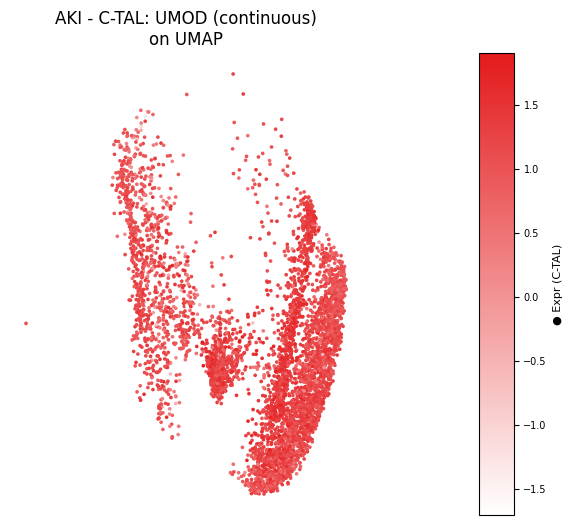

▶ Saved figures/genes/UMOD/AKI/pca/C-TAL.png/AKI/pca/C-TAL.png


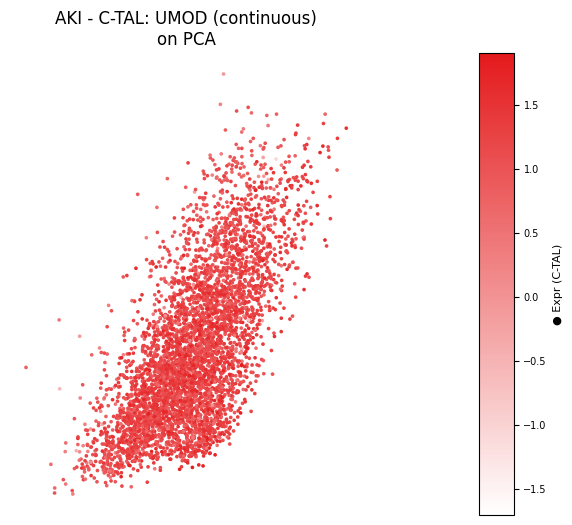

  Subclass: M-TAL
▶ Saved figures/genes/UMOD/AKI/umap/M-TAL.png/AKI/umap/M-TAL.png


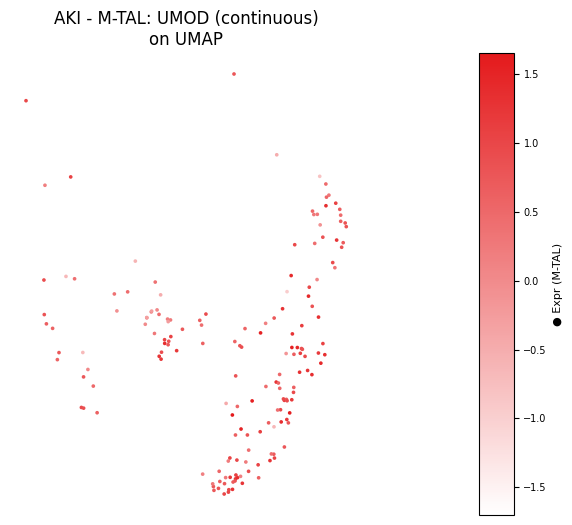

▶ Saved figures/genes/UMOD/AKI/pca/M-TAL.png/AKI/pca/M-TAL.png


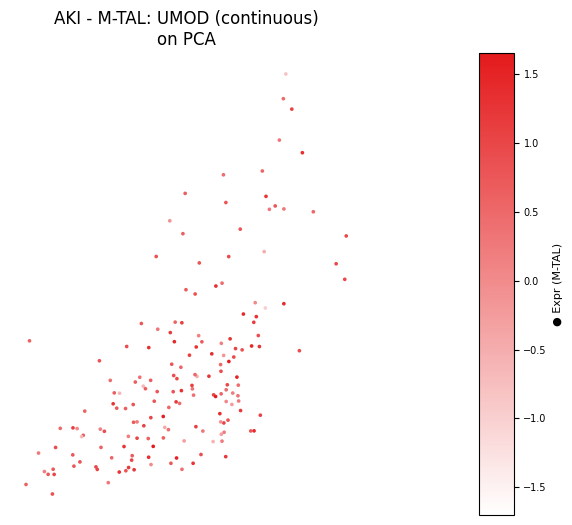

  Subclass: aTAL
▶ Saved figures/genes/UMOD/AKI/umap/aTAL.png/AKI/umap/aTAL.png


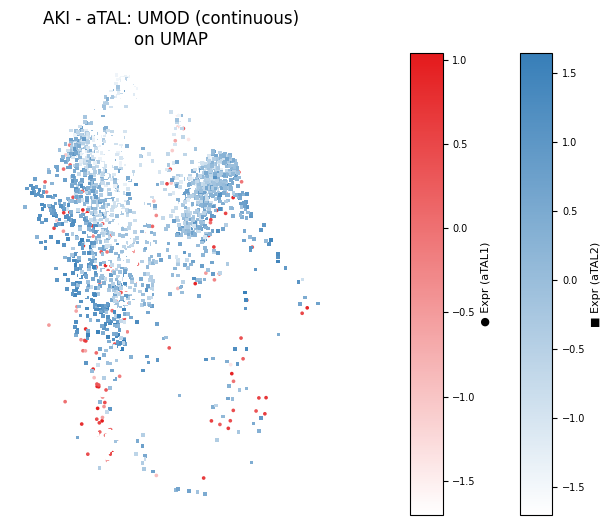

▶ Saved figures/genes/UMOD/AKI/pca/aTAL.png/AKI/pca/aTAL.png


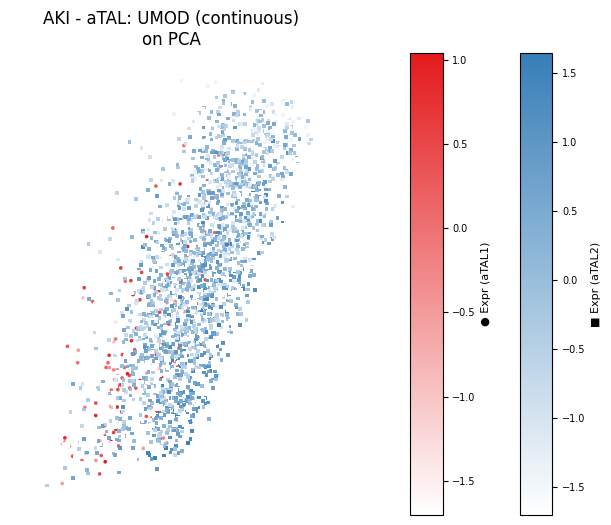

Processing disease: CKD
  Subclass: C-TAL
▶ Saved figures/genes/UMOD/CKD/umap/C-TAL.png/CKD/umap/C-TAL.png


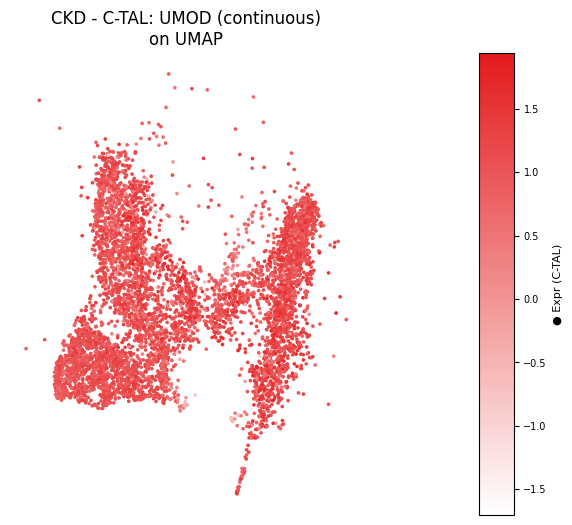

▶ Saved figures/genes/UMOD/CKD/pca/C-TAL.png/CKD/pca/C-TAL.png


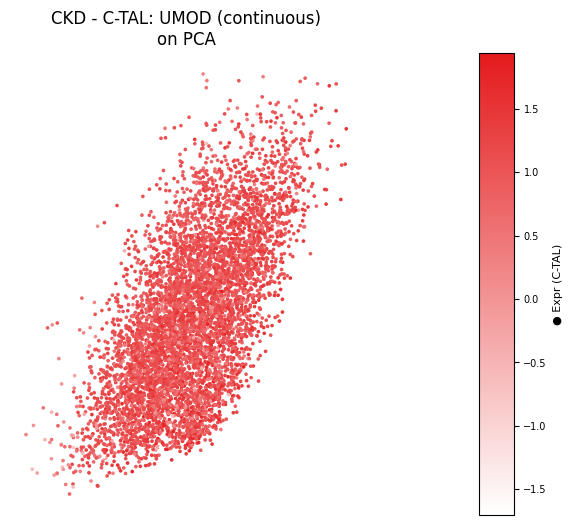

  Subclass: M-TAL
▶ Saved figures/genes/UMOD/CKD/umap/M-TAL.png/CKD/umap/M-TAL.png


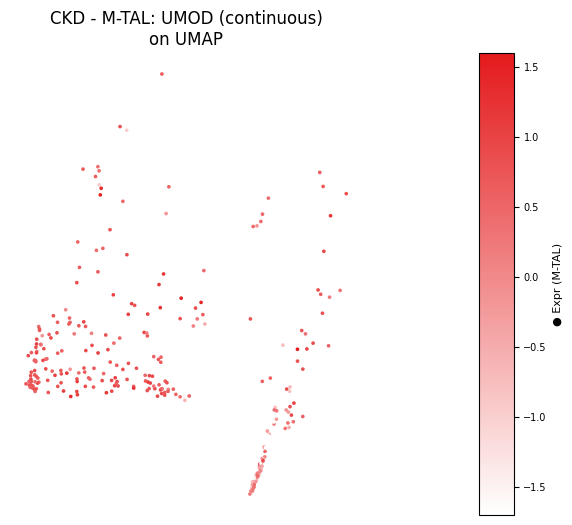

▶ Saved figures/genes/UMOD/CKD/pca/M-TAL.png/CKD/pca/M-TAL.png


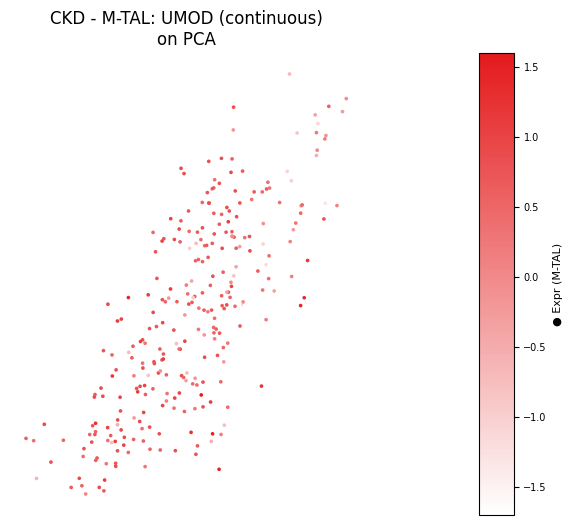

  Subclass: aTAL
▶ Saved figures/genes/UMOD/CKD/umap/aTAL.png/CKD/umap/aTAL.png


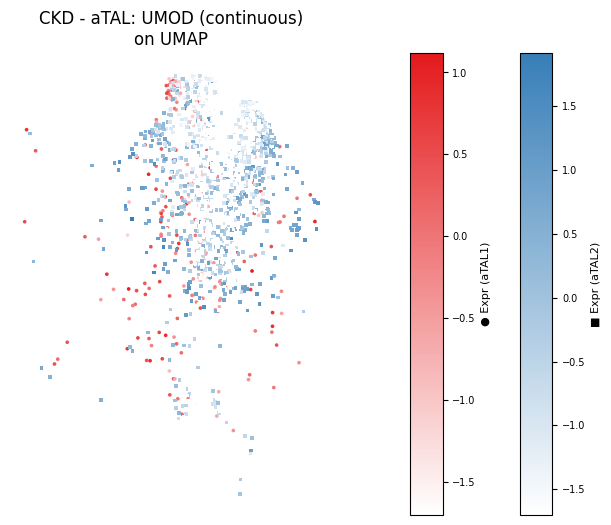

▶ Saved figures/genes/UMOD/CKD/pca/aTAL.png/CKD/pca/aTAL.png


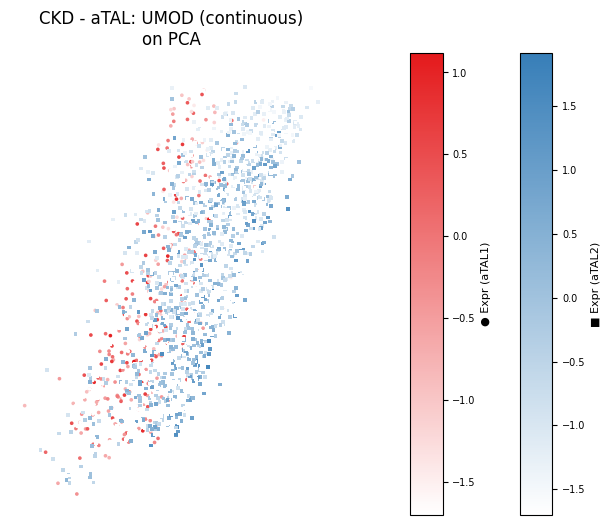

Processing disease: Reference
  Subclass: C-TAL
▶ Saved figures/genes/UMOD/Reference/umap/C-TAL.png/Reference/umap/C-TAL.png


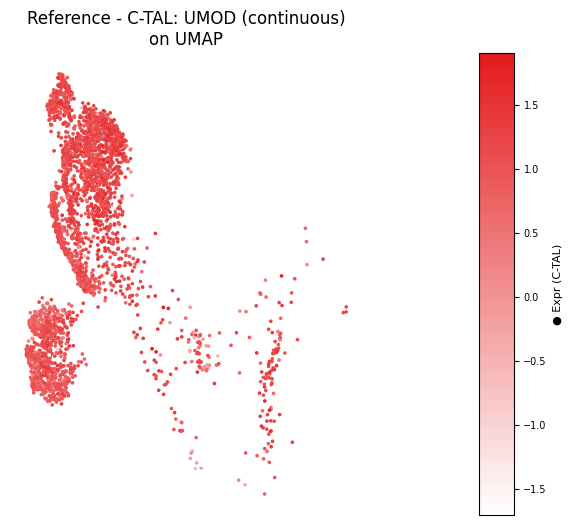

▶ Saved figures/genes/UMOD/Reference/pca/C-TAL.png/Reference/pca/C-TAL.png


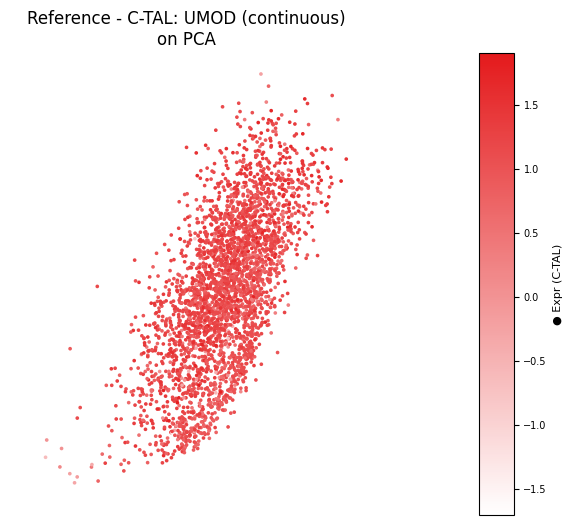

  Subclass: M-TAL
▶ Saved figures/genes/UMOD/Reference/umap/M-TAL.png/Reference/umap/M-TAL.png


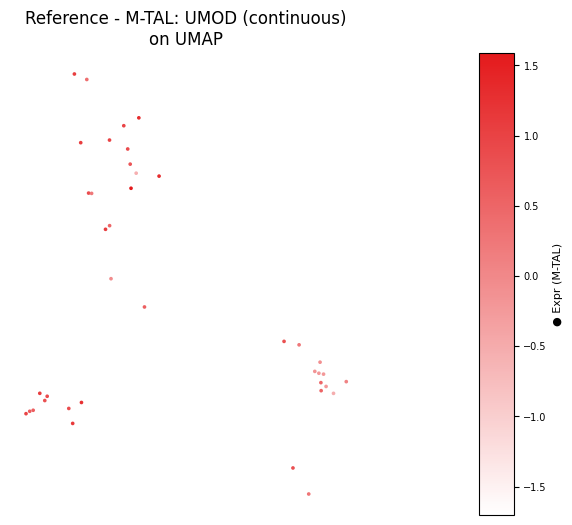

▶ Saved figures/genes/UMOD/Reference/pca/M-TAL.png/Reference/pca/M-TAL.png


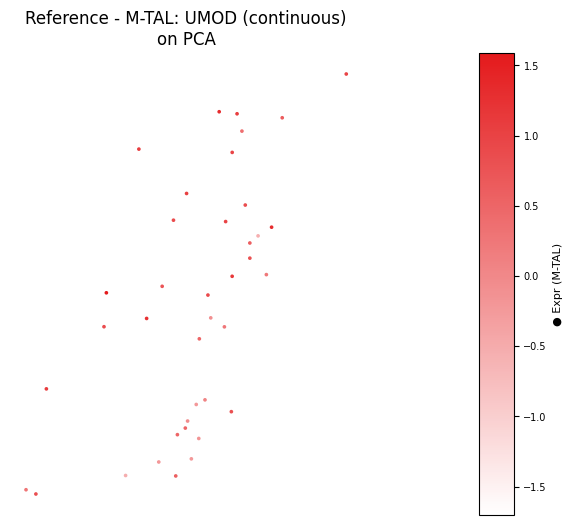

  Subclass: aTAL
▶ Saved figures/genes/UMOD/Reference/umap/aTAL.png/Reference/umap/aTAL.png


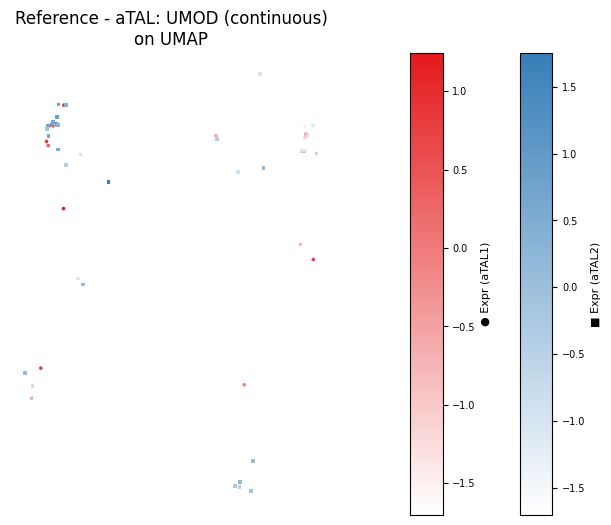

▶ Saved figures/genes/UMOD/Reference/pca/aTAL.png/Reference/pca/aTAL.png


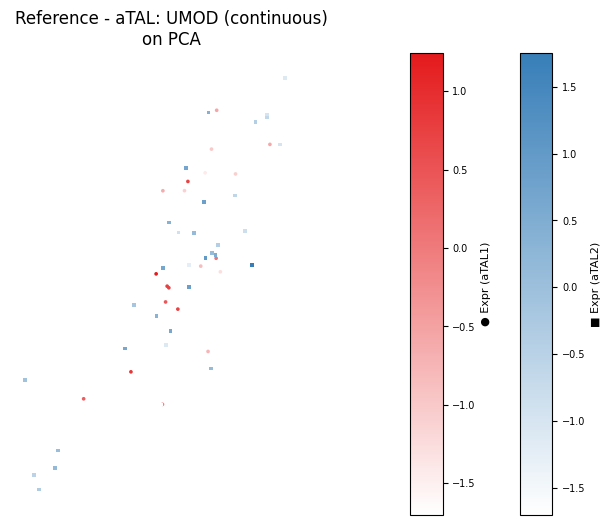

Processing disease: AKI
  Subclass: C-TAL
▶ Saved figures/genes/SLC12A1/AKI/umap/C-TAL.png/AKI/umap/C-TAL.png


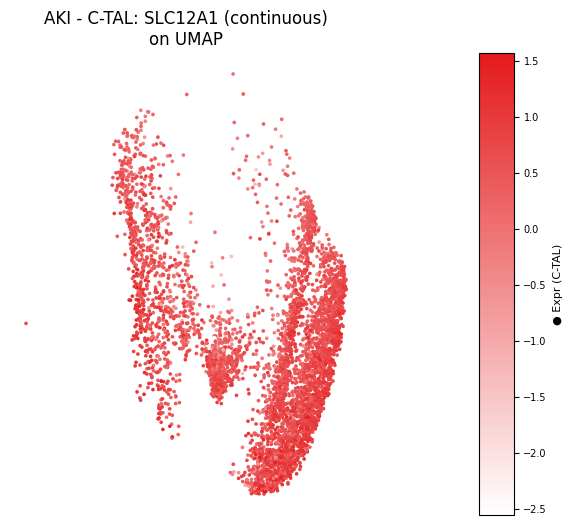

▶ Saved figures/genes/SLC12A1/AKI/pca/C-TAL.png/AKI/pca/C-TAL.png


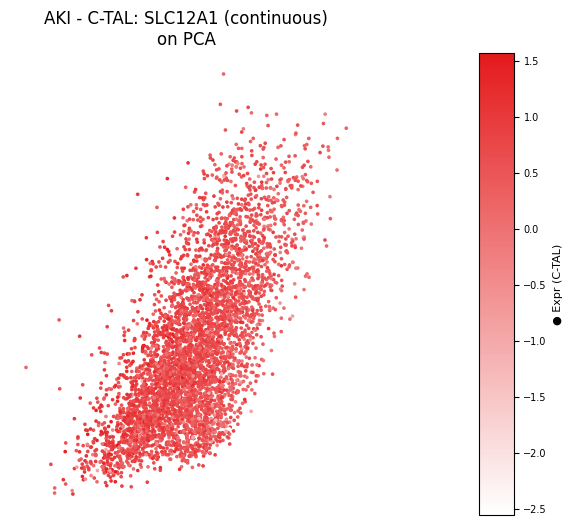

  Subclass: M-TAL
▶ Saved figures/genes/SLC12A1/AKI/umap/M-TAL.png/AKI/umap/M-TAL.png


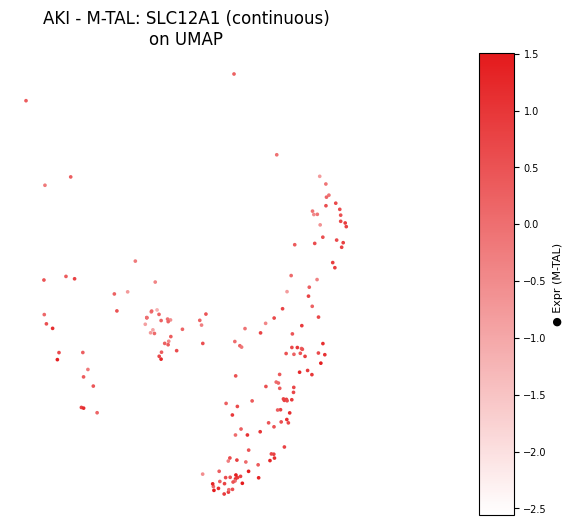

▶ Saved figures/genes/SLC12A1/AKI/pca/M-TAL.png/AKI/pca/M-TAL.png


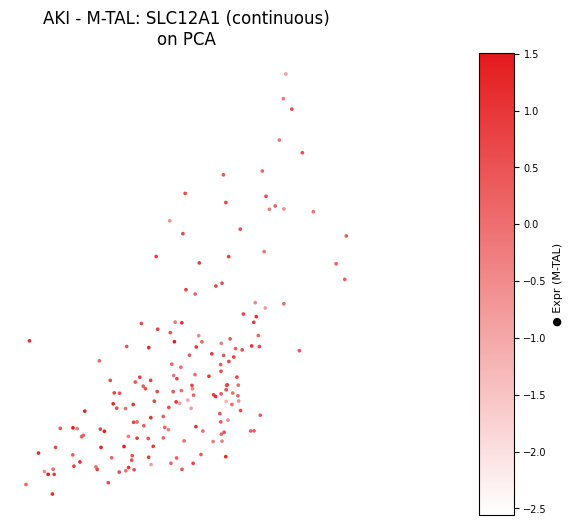

  Subclass: aTAL
▶ Saved figures/genes/SLC12A1/AKI/umap/aTAL.png/AKI/umap/aTAL.png


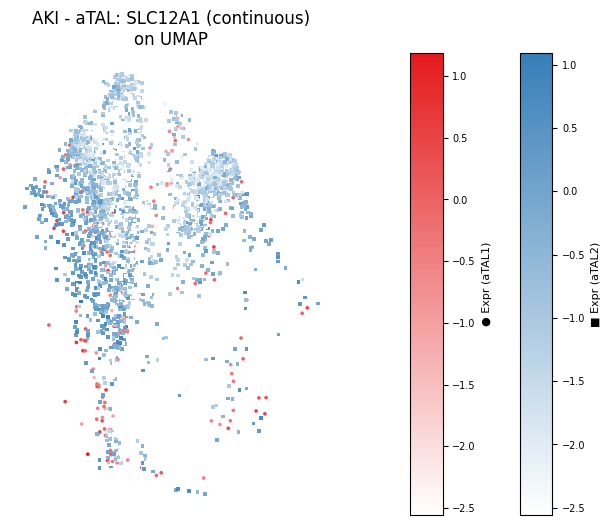

▶ Saved figures/genes/SLC12A1/AKI/pca/aTAL.png/AKI/pca/aTAL.png


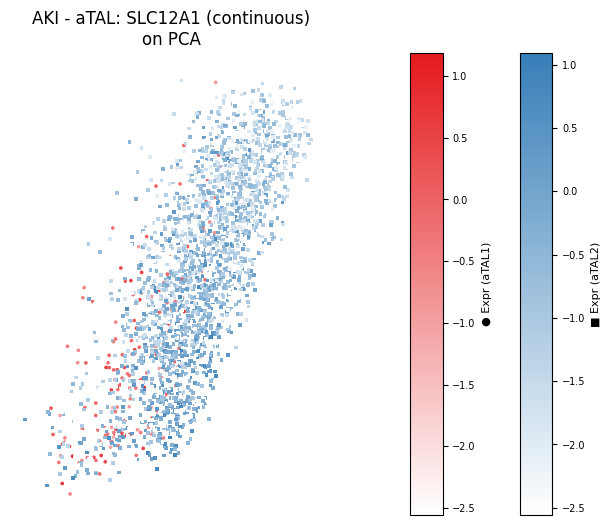

Processing disease: CKD
  Subclass: C-TAL
▶ Saved figures/genes/SLC12A1/CKD/umap/C-TAL.png/CKD/umap/C-TAL.png


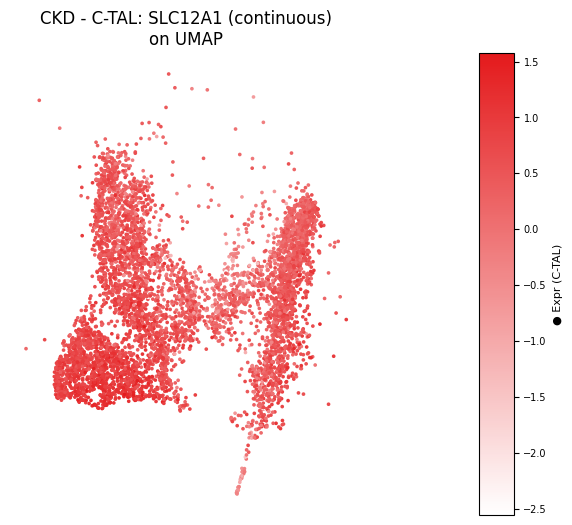

▶ Saved figures/genes/SLC12A1/CKD/pca/C-TAL.png/CKD/pca/C-TAL.png


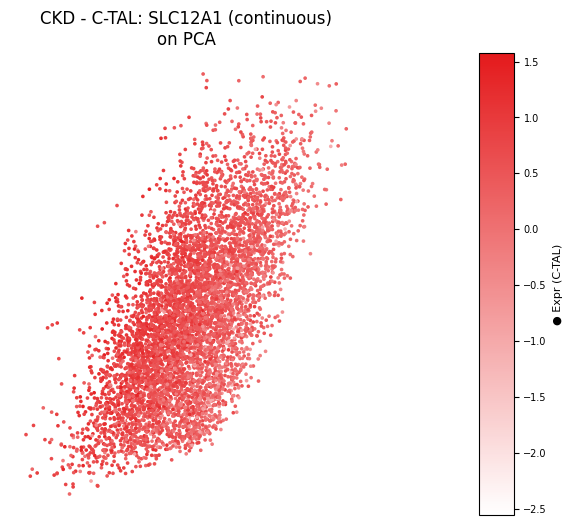

  Subclass: M-TAL
▶ Saved figures/genes/SLC12A1/CKD/umap/M-TAL.png/CKD/umap/M-TAL.png


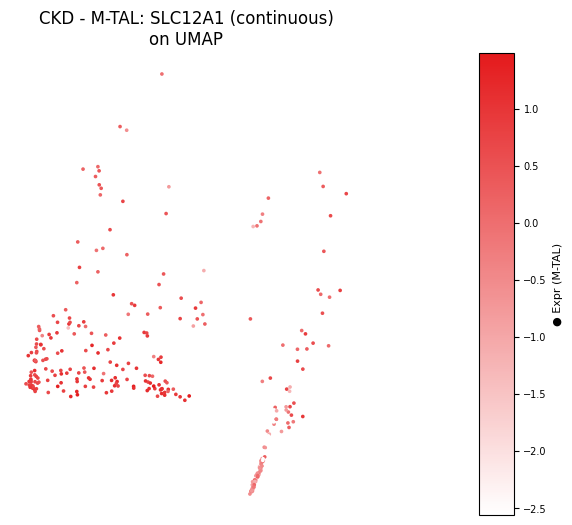

▶ Saved figures/genes/SLC12A1/CKD/pca/M-TAL.png/CKD/pca/M-TAL.png


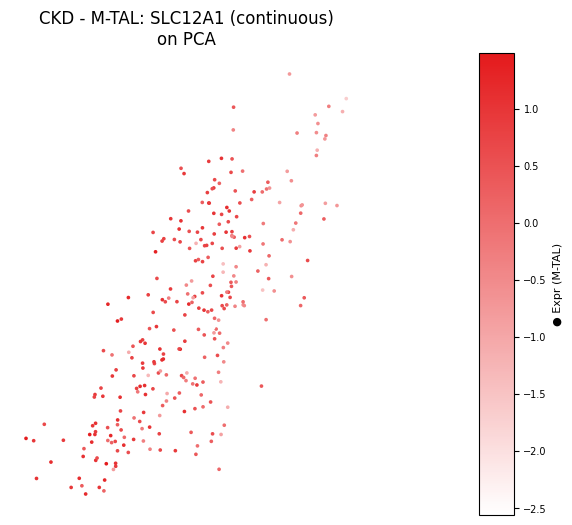

  Subclass: aTAL
▶ Saved figures/genes/SLC12A1/CKD/umap/aTAL.png/CKD/umap/aTAL.png


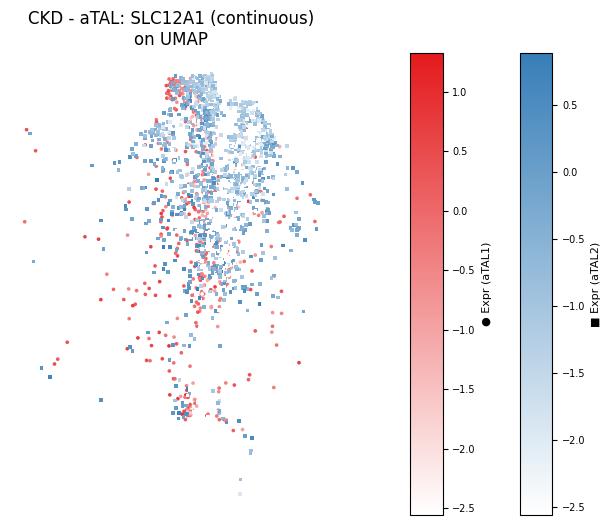

▶ Saved figures/genes/SLC12A1/CKD/pca/aTAL.png/CKD/pca/aTAL.png


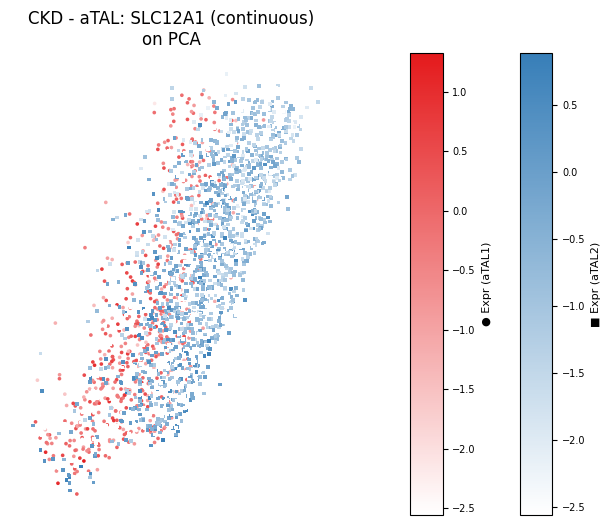

Processing disease: Reference
  Subclass: C-TAL
▶ Saved figures/genes/SLC12A1/Reference/umap/C-TAL.png/Reference/umap/C-TAL.png


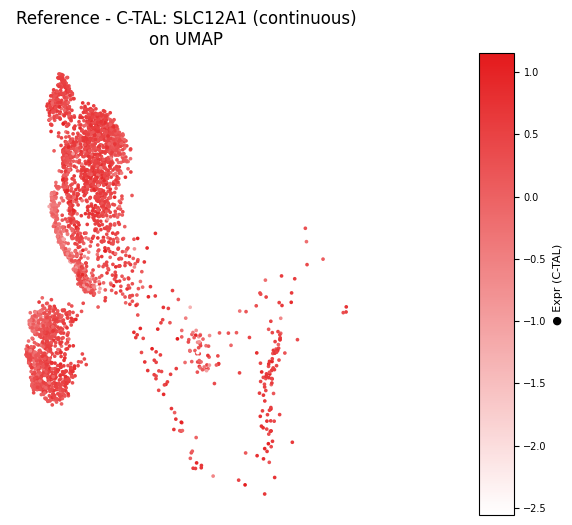

▶ Saved figures/genes/SLC12A1/Reference/pca/C-TAL.png/Reference/pca/C-TAL.png


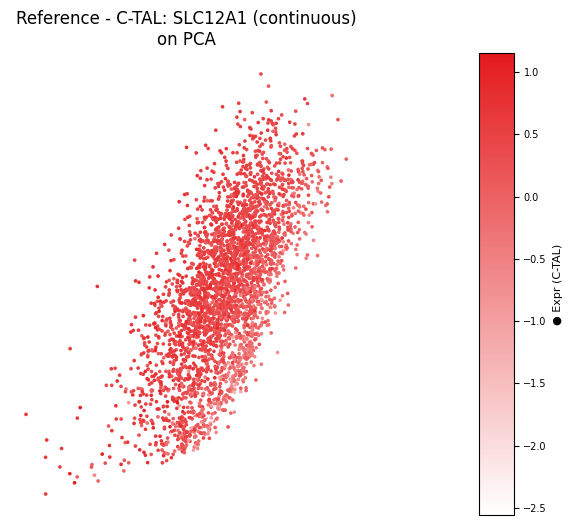

  Subclass: M-TAL
▶ Saved figures/genes/SLC12A1/Reference/umap/M-TAL.png/Reference/umap/M-TAL.png


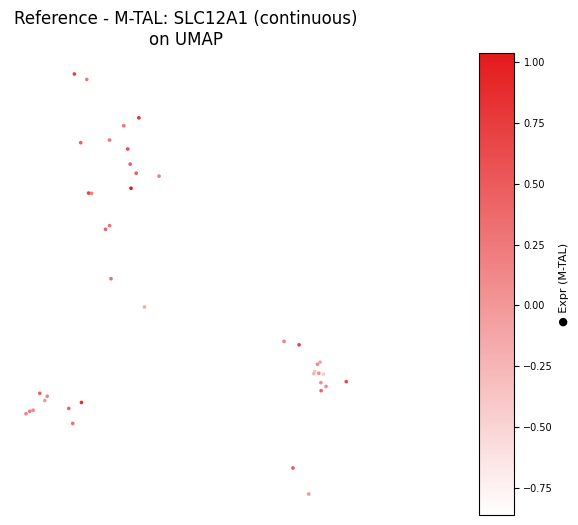

▶ Saved figures/genes/SLC12A1/Reference/pca/M-TAL.png/Reference/pca/M-TAL.png


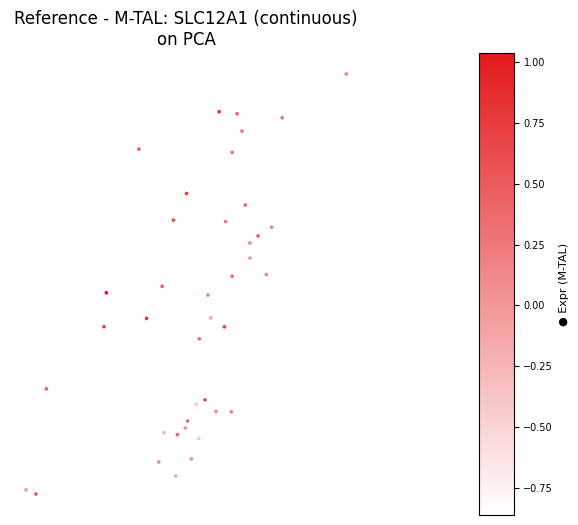

  Subclass: aTAL
▶ Saved figures/genes/SLC12A1/Reference/umap/aTAL.png/Reference/umap/aTAL.png


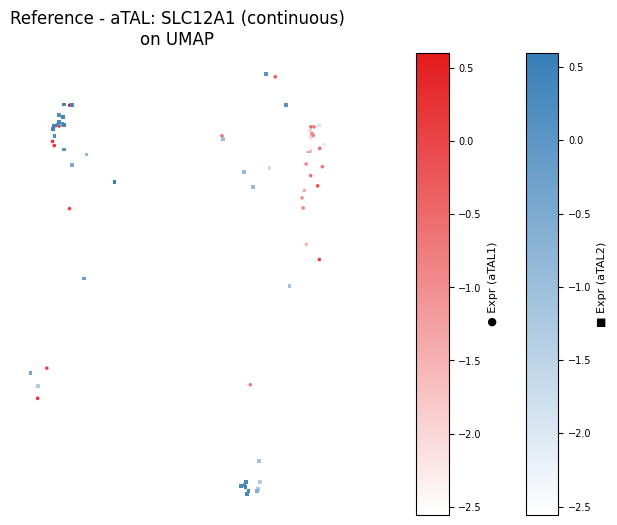

▶ Saved figures/genes/SLC12A1/Reference/pca/aTAL.png/Reference/pca/aTAL.png


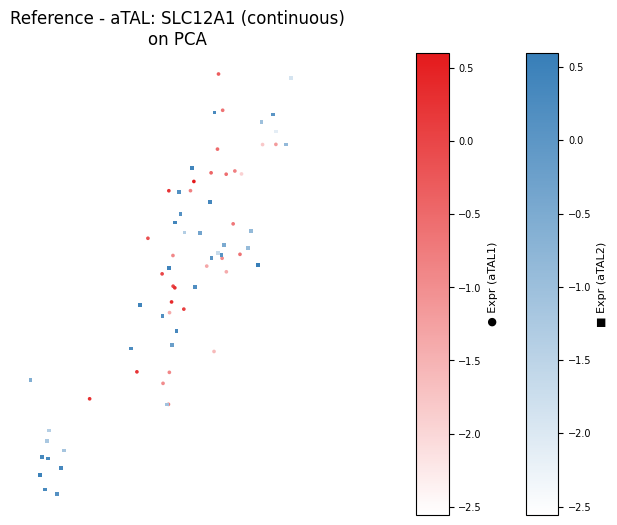

In [7]:
for gene in genes:
    for disease, acronym in diseases.items():
        adata_filtered_disease = adata_filtered[
            adata_filtered.obs["disease"] == disease
        ].copy()
        print(f"Processing disease: {acronym}")
        for subclass in adata_filtered_disease.obs["merged_subclass"].cat.categories:
            adata_filtered_subclass = adata_filtered_disease[
                adata_filtered_disease.obs["merged_subclass"] == subclass
            ].copy()
            print(f"  Subclass: {subclass}")
            fig, ax = plot_gene_embedding(
                adata=adata_filtered_subclass,
                gene=gene,
                emb_key="X_umap",
                title_prefix=f"{acronym} - {subclass}",
                cmap="Set1",
                save=True,
                filename=f"{acronym}/umap/{subclass}.png",
            )
            fig, ax = plot_gene_embedding(
                adata=adata_filtered_subclass,
                gene=gene,
                emb_key="X_pca",
                title_prefix=f"{acronym} - {subclass}",
                cmap="Set1",
                save=True,
                filename=f"{acronym}/pca/{subclass}.png",
            )

FileNotFoundError: [Errno 2] No such file or directory: 'figures/genes/X_umap/combined_UMOD_thr0.1.png'

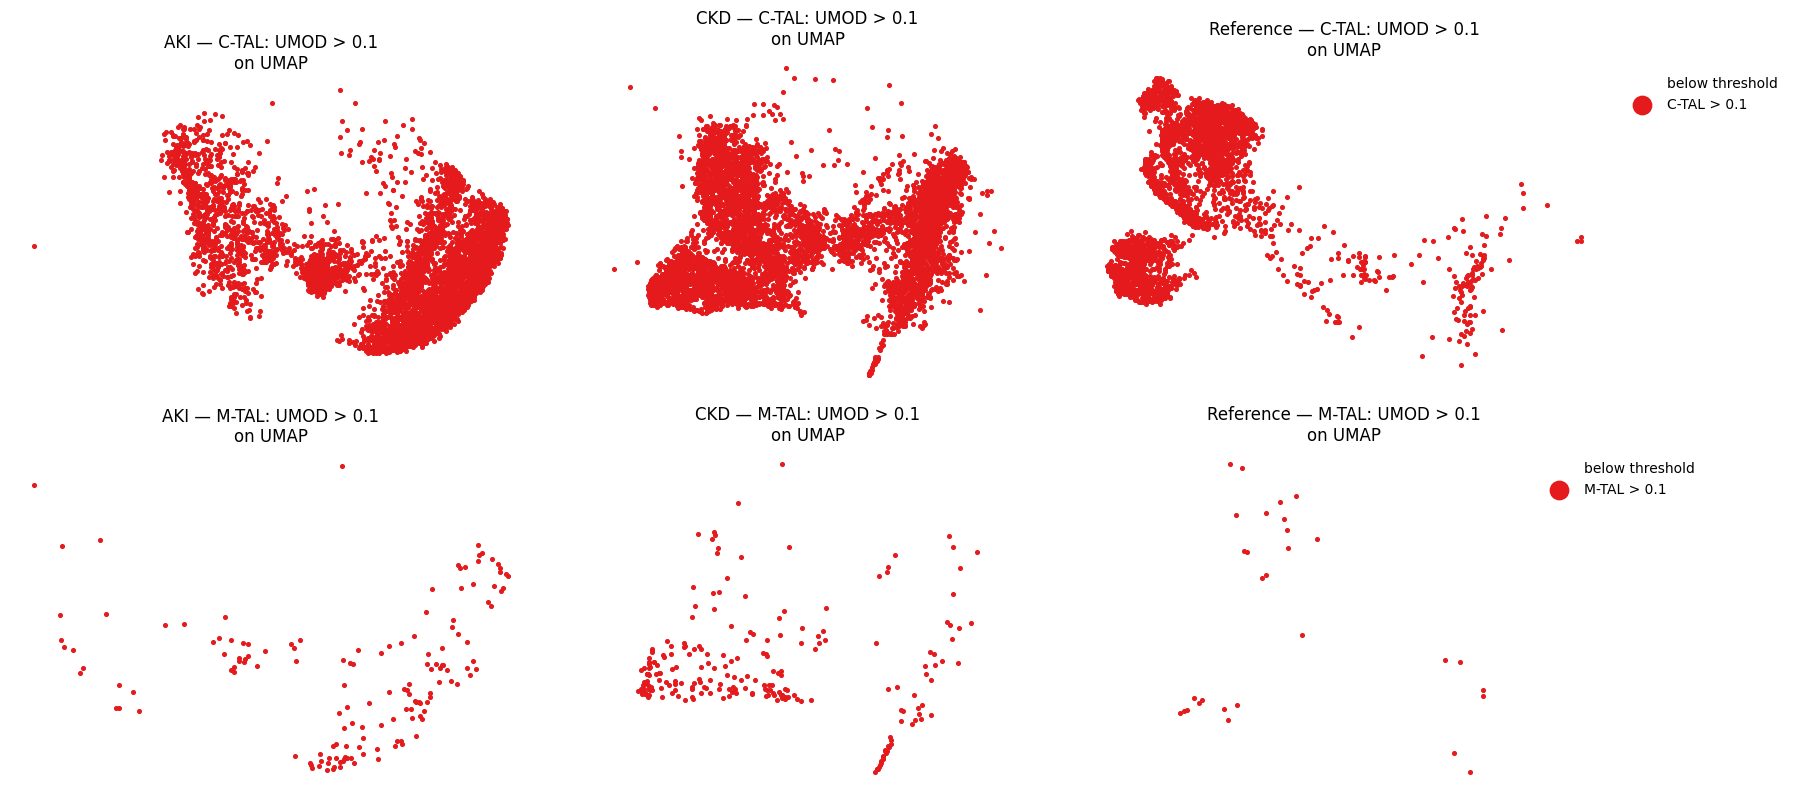

In [8]:
subclasses = adata_filtered.obs["subclass.l2"].cat.categories.tolist()
n_rows = len(subclasses)
n_cols = len(diseases)

_original_show = plt.show
plt.show = lambda *a, **k: None

embeddings = ["X_umap", "X_pca"]

for emb_key in embeddings:
    embedding_name = emb_key.replace("X_", "").upper()

    for gene in genes:
        for threshold in thresholds:
            plt.close("all")

            subclasses = adata_filtered.obs["subclass.l2"].cat.categories.tolist()
            n_rows, n_cols = len(subclasses), len(diseases)
            fig = plt.figure(figsize=(6 * n_cols, 4 * n_rows))
            gs = GridSpec(n_rows, n_cols, figure=fig)
            fig.subplots_adjust(wspace=0.5, hspace=0.4)

            for i, subclass in enumerate(subclasses):
                for j, (disease, acronym) in enumerate(diseases.items()):
                    ad = adata_filtered[
                        (adata_filtered.obs["disease"] == disease)
                        & (adata_filtered.obs["merged_subclass"] == subclass)
                    ]
                    if ad.n_obs == 0:
                        continue

                    small_fig, small_ax = plot_gene_embedding(
                        adata=ad,
                        gene=gene,
                        threshold=threshold,
                        title_prefix=f"{acronym} — {subclass}",
                        emb_key=emb_key,
                        cmap="Set1",
                        save=False,
                        show_legend=False,
                    )

                    ax = fig.add_subplot(gs[i, j])
                    for coll in small_ax.collections:
                        ax.scatter(
                            coll.get_offsets()[:, 0],
                            coll.get_offsets()[:, 1],
                            s=coll.get_sizes(),
                            c=coll.get_facecolors(),
                            alpha=coll.get_alpha(),
                            label=coll.get_label(),
                        )
                    ax.set_title(small_ax.get_title())
                    ax.set_xlim(small_ax.get_xlim())
                    ax.set_ylim(small_ax.get_ylim())
                    ax.set_aspect("equal", adjustable="box")
                    ax.axis("off")

                    if j == n_cols - 1:
                        handles, labels = ax.get_legend_handles_labels()
                        by_label = dict(zip(labels, handles))
                        ax.legend(
                            by_label.values(),
                            by_label.keys(),
                            bbox_to_anchor=(1.02, 1),
                            loc="upper left",
                            frameon=False,
                            markerscale=5,
                        )

                    plt.close(small_fig)

            plt.show = _original_show
            fig.tight_layout()
            os.makedirs(f"figures/genes", exist_ok=True)
            fn = f"figures/genes/{emb_key}/combined_{gene}_thr{threshold:.1f}.png"
            fig.savefig(fn, dpi=300, bbox_inches="tight")
            print(f"▶ Saved {fn}")
            plt.close(fig)